Loading Datasets

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("GSE330057_dataset.csv")
df.head()

,GENEID,CRT3,TCRT_ICAM2-3,TCRT_ICAM2-1,CRT2,CRT1,TCRT_ICAM2-2
0,A1BG,476,688,648,502,612,653
1,A1BG-AS1,509,541,499,475,535,499
2,A2M-AS1,0,1,1,0,0,1
3,A3GALT2,2,0,0,0,1,0
4,A4GALT,2,0,1,1,7,0


Set Gene Column as index

In [3]:
df=df.set_index("GENEID")
df.head()

,CRT3,TCRT_ICAM2-3,TCRT_ICAM2-1,CRT2,CRT1,TCRT_ICAM2-2
GENEID,,,,,,
A1BG,476,688,648,502,612,653
A1BG-AS1,509,541,499,475,535,499
A2M-AS1,0,1,1,0,0,1
A3GALT2,2,0,0,0,1,0
A4GALT,2,0,1,1,7,0


Separate Groups(TCRT vs. CRT)

In [4]:
df.columns

Index(['CRT3', 'TCRT_ICAM2-3', 'TCRT_ICAM2-1', 'CRT2', 'CRT1', 'TCRT_ICAM2-2'], dtype='object')

In [5]:
crt=df[["CRT1", "CRT2", "CRT3"]]
crt.head()

,CRT1,CRT2,CRT3
GENEID,,,
A1BG,612,502,476
A1BG-AS1,535,475,509
A2M-AS1,0,0,0
A3GALT2,1,0,2
A4GALT,7,1,2


In [6]:
tcrt=df[["TCRT_ICAM2-1", "TCRT_ICAM2-2", "TCRT_ICAM2-3"]]
tcrt.head()

,TCRT_ICAM2-1,TCRT_ICAM2-2,TCRT_ICAM2-3
GENEID,,,
A1BG,648,653,688
A1BG-AS1,499,499,541
A2M-AS1,1,1,1
A3GALT2,0,0,0
A4GALT,1,0,0


In [7]:
df_numeric = df.apply(pd.to_numeric, errors='coerce')

In [8]:
df_filtered = df_numeric[(df_numeric > 1).sum(axis=1) >= 2]

crt = df_filtered[["CRT1", "CRT2", "CRT3"]]
tcrt = df_filtered[["TCRT_ICAM2-1", "TCRT_ICAM2-2", "TCRT_ICAM2-3"]]

print(f"Genes before filtering: {len(df_numeric)}")
print(f"Genes after filtering: {len(df_filtered)}")

Genes before filtering: 20812
Genes after filtering: 17077


Log transformation

In [9]:
import numpy as np

crt_log=np.log2(crt+1)
tcrt_log=np.log2(tcrt+1)

In [10]:
crt_log.head()

,CRT1,CRT2,CRT3
GENEID,,,
A1BG,9.259743,8.974415,8.897845
A1BG-AS1,9.066089,8.894818,8.994353
A4GALT,3.000000,1.000000,1.584963
AAAS,11.704768,11.505315,11.537218
AACS,12.028597,11.913263,11.892543


In [11]:
tcrt_log.head()

,TCRT_ICAM2-1,TCRT_ICAM2-2,TCRT_ICAM2-3
GENEID,,,
A1BG,9.342075,9.353147,9.428360
A1BG-AS1,8.965784,8.965784,9.082149
A4GALT,1.000000,0.000000,0.000000
AAAS,11.741467,11.607793,11.604553
AACS,11.776022,11.722381,11.742309


Mean Expression

In [12]:
crt_mean=crt_log.mean(axis=1)
tcrt_mean=tcrt_log.mean(axis=1)

In [13]:
crt_mean.head()

GENEID
A1BG         9.044001
A1BG-AS1     8.985087
A4GALT       1.861654
AAAS        11.582434
AACS        11.944801
dtype: float64

In [14]:
tcrt_mean.head()

GENEID
A1BG         9.374527
A1BG-AS1     9.004573
A4GALT       0.333333
AAAS        11.651271
AACS        11.746904
dtype: float64

Computing log fold change

In [15]:
logFC=tcrt_mean-crt_mean
logFC.head()

GENEID
A1BG        0.330526
A1BG-AS1    0.019486
A4GALT     -1.528321
AAAS        0.068837
AACS       -0.197897
dtype: float64

Statistical Testing

In [16]:
from scipy.stats import ttest_ind

p_values = []

for gene in df_filtered.index:
    stat, p = ttest_ind(
        crt_log.loc[gene],
        tcrt_log.loc[gene],
        equal_var=False
    )
    p_values.append(p)


c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Building result table

In [17]:
results = pd.DataFrame({
    "logFC": logFC,
    "p_value": p_values,
}, index=df_filtered.index)


In [18]:
import pandas as pd

results=pd.DataFrame({
    "logFC":logFC,
    "p_value":p_values,
 })

results.head()

,logFC,p_value
GENEID,,
A1BG,0.330526,0.087737
A1BG-AS1,0.019486,0.773435
A4GALT,-1.528321,0.106330
AAAS,0.068837,0.423804
AACS,-0.197897,0.030797


In [48]:
from statsmodels.stats.multitest import multipletests

results['adj_p'] = multipletests(results['p_value'], method='fdr_bh')[1]

In [22]:
print("NaN in adj_p:", results["adj_p"].isna().sum())
print("Significant genes (adj_p < 0.05, |logFC| > 1):",
      ((results["adj_p"] < 0.05) & (results["logFC"].abs() > 1)).sum())

results.head()

NaN in adj_p: 0
Significant genes (adj_p < 0.05, |logFC| > 1): 1267


,logFC,p_value,adj_p,-log10_p
GENEID,,,,
A1BG,0.330526,0.087737,0.169471,1.056816
A1BG-AS1,0.019486,0.773435,0.837643,0.111576
A4GALT,-1.528321,0.106330,0.194369,0.973346
AAAS,0.068837,0.423804,0.539172,0.372835
AACS,-0.197897,0.030797,0.085101,1.511488


Significance filter

In [23]:
significant = results[
    (results["adj_p"] < 0.05) &
    (abs(results["logFC"]) > 1)
] 

significant.head()

,logFC,p_value,adj_p,-log10_p
GENEID,,,,
AARD,-2.134168,0.000996,0.016202,3.001798
AASS,2.226570,0.007972,0.039774,2.098414
ABAT,-1.083175,0.000265,0.009992,3.576674
ABCA1,2.302297,0.005354,0.033025,2.271282
ABCB6,1.164613,0.000060,0.005691,4.224394


Volcano Plot

In [24]:
import numpy as np
results["-log10_p"] = -np.log10(results["p_value"])

c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


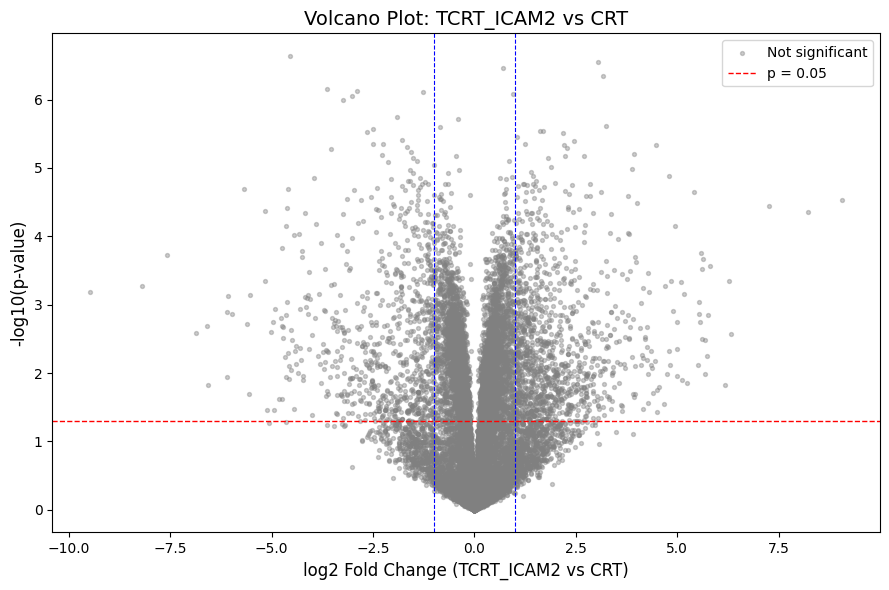

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Volcano Plot 1: Basic ---
plt.figure(figsize=(9, 6))
plt.scatter(results["logFC"], results["-log10_p"], alpha=0.4, color="grey", s=8, label="Not significant")
plt.axhline(y=-np.log10(0.05), color="red", linestyle="--", linewidth=1, label="p = 0.05")  # FIX: was np.log10, now -np.log10
plt.axvline(x=1, color="blue", linestyle="--", linewidth=0.8)
plt.axvline(x=-1, color="blue", linestyle="--", linewidth=0.8)
plt.xlabel("log2 Fold Change (TCRT_ICAM2 vs CRT)", fontsize=12)
plt.ylabel("-log10(p-value)", fontsize=12)
plt.title("Volcano Plot: TCRT_ICAM2 vs CRT", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

To highlight significant genes

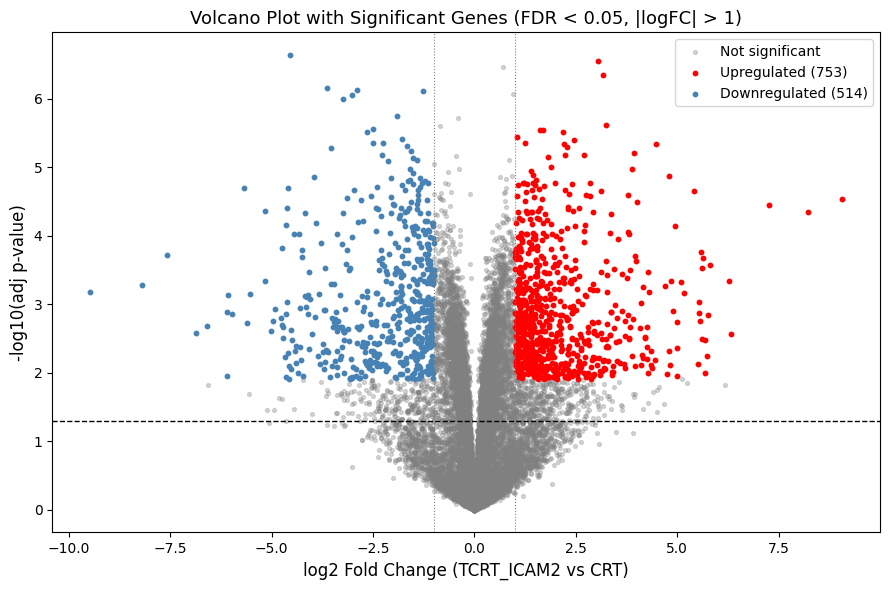

Total significant DEGs: 1267
Upregulated: 753 | Downregulated: 514


In [27]:

sig = results[(results["adj_p"] < 0.05) & (results["logFC"].abs() > 1)]
up = sig[sig["logFC"] > 1]
down = sig[sig["logFC"] < -1]

plt.figure(figsize=(9, 6))
plt.scatter(results["logFC"], results["-log10_p"], alpha=0.3, color="grey", s=8, label="Not significant")
plt.scatter(up["logFC"], up["-log10_p"], color="red", s=10, label=f"Upregulated ({len(up)})")
plt.scatter(down["logFC"], down["-log10_p"], color="steelblue", s=10, label=f"Downregulated ({len(down)})")
plt.axhline(y=-np.log10(0.05), color="black", linestyle="--", linewidth=1)
plt.axvline(x=1, color="grey", linestyle=":", linewidth=0.8)
plt.axvline(x=-1, color="grey", linestyle=":", linewidth=0.8)
plt.xlabel("log2 Fold Change (TCRT_ICAM2 vs CRT)", fontsize=12)
plt.ylabel("-log10(adj p-value)", fontsize=12)
plt.title("Volcano Plot with Significant Genes (FDR < 0.05, |logFC| > 1)", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Total significant DEGs: {len(sig)}")
print(f"Upregulated: {len(up)} | Downregulated: {len(down)}")

Hypothesis Gene Lookup

In [28]:

hypothesis_genes = ["FOXO1", "ICAM2", "RORC", "TCF7", "TOX", "IL6",
                    "ENTPD1", "CCR7", "MKI67", "SELL", "BCL2"]

print("=== Hypothesis Gene Results ===\n")
for gene in hypothesis_genes:
    if gene in results.index:
        row = results.loc[gene]
        direction = "UP" if row["logFC"] > 0 else "DOWN"
        sig_flag = "✓ SIGNIFICANT" if row["adj_p"] < 0.05 else ""
        print(f"{gene:<15} logFC={row['logFC']:>7.3f}  p={row['p_value']:.4f}  adj_p={row['adj_p']:.4f}  [{direction}] {sig_flag}")
    else:
        print(f"{gene:<15} — not found in dataset")

=== Hypothesis Gene Results ===

FOXO1           logFC=  0.094  p=0.3674  adj_p=0.4838  [UP] 
ICAM2           logFC=  0.405  p=0.0031  adj_p=0.0253  [UP] ✓ SIGNIFICANT
RORC            logFC=  5.748  p=0.0014  adj_p=0.0187  [UP] ✓ SIGNIFICANT
TCF7            logFC= -0.036  p=0.6064  adj_p=0.7039  [DOWN] 
TOX             logFC= -0.989  p=0.0014  adj_p=0.0186  [DOWN] ✓ SIGNIFICANT
IL6             logFC= -6.069  p=0.0007  adj_p=0.0143  [DOWN] ✓ SIGNIFICANT
ENTPD1          logFC= -9.479  p=0.0007  adj_p=0.0137  [DOWN] ✓ SIGNIFICANT
CCR7            logFC=  0.310  p=0.0050  adj_p=0.0319  [UP] ✓ SIGNIFICANT
MKI67           logFC=  0.157  p=0.0503  adj_p=0.1167  [UP] 
SELL            logFC=  0.161  p=0.0243  adj_p=0.0733  [UP] 
BCL2            logFC= -0.262  p=0.0135  adj_p=0.0526  [DOWN] 


Upregulated and Downregulated Genes

In [29]:
top_up = results[results["p_value"] < 0.05].sort_values("logFC", ascending=False).head(10)
print("=== Top 10 Upregulated Genes ===")
print(top_up[["logFC", "p_value", "adj_p"]].to_string())

=== Top 10 Upregulated Genes ===
                          logFC   p_value     adj_p
GENEID                                             
SHTN1                  9.066248  0.000029  0.004316
ABO                    8.217058  0.000045  0.005067
IGFBP2                 7.270503  0.000036  0.004819
LOC107985558           6.312921  0.002716  0.023793
ADAM12                 6.260931  0.000457  0.011913
KIF19                  6.169393  0.014964  0.055757
ANKRD20A4-ANKRD20A20P  5.801143  0.000271  0.010004
RORC                   5.747900  0.001430  0.018685
PADI4                  5.731859  0.005639  0.033752
S1PR5                  5.690503  0.010261  0.045230


In [30]:
top_down = results[results["p_value"] < 0.05].sort_values("logFC", ascending=True).head(10)
print("\n=== Top 10 Downregulated Genes ===")
print(top_down[["logFC", "p_value", "adj_p"]].to_string())


=== Top 10 Downregulated Genes ===
           logFC   p_value     adj_p
GENEID                              
ENTPD1 -9.479227  0.000654  0.013680
MB     -8.186218  0.000529  0.012605
DMD    -7.584989  0.000190  0.009095
FN1    -6.854588  0.002631  0.023419
CCL1   -6.602150  0.002082  0.021295
LRFN2  -6.556109  0.014971  0.055757
AKAP12 -6.104969  0.001289  0.018080
PEAR1  -6.091968  0.011243  0.047382
IL6    -6.068857  0.000742  0.014333
PRSS2  -5.981944  0.001382  0.018477


Heatmap of top DEGs

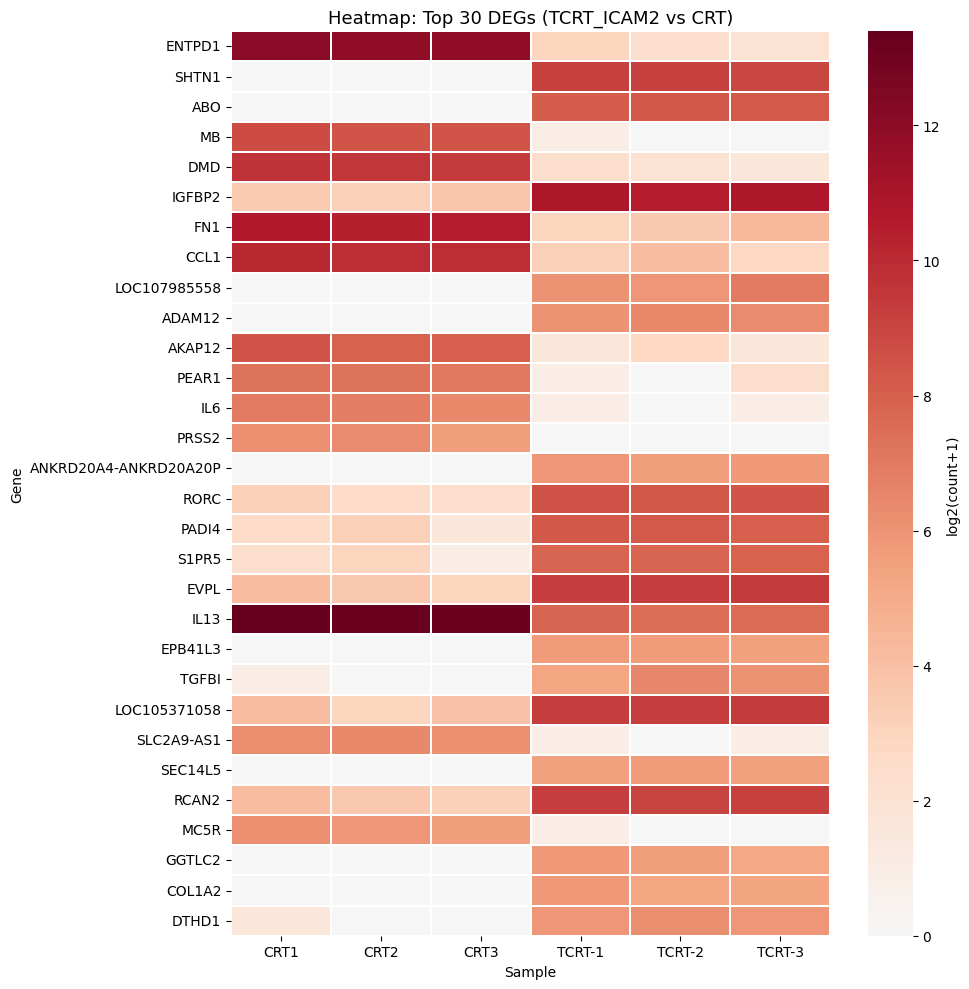

In [31]:
import seaborn as sns

# Get top 30 significant DEGs by absolute logFC
top_degs = sig.reindex(sig["logFC"].abs().sort_values(ascending=False).index).head(30)
heatmap_data = pd.concat([
    crt_log.loc[top_degs.index],
    tcrt_log.loc[top_degs.index]
], axis=1)

# Rename columns for clarity
heatmap_data.columns = ["CRT1", "CRT2", "CRT3", "TCRT-1", "TCRT-2", "TCRT-3"]

plt.figure(figsize=(10, 10))
sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",
    center=0,
    linewidths=0.3,
    linecolor="white",
    yticklabels=True,
    cbar_kws={"label": "log2(count+1)"}
)
plt.title("Heatmap: Top 30 DEGs (TCRT_ICAM2 vs CRT)", fontsize=13)
plt.xlabel("Sample")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

GO Enrichment

Significant filtering of DEGs by adj_p

In [50]:
significant_genes = results[
    (results["adj_p"] < 0.05) & (results["logFC"].abs() > 1)
].index.tolist()

print("Gene list size:", len(significant_genes))

Gene list size: 1267


In [52]:
import gseapy as gp

enr = gp.enrichr(
    gene_list=significant_genes,
    gene_sets="GO_Biological_Process_2023",
    organism="hsapiens",
    outdir=None
)

print("Enrichment Successful")

Enrichment Successful


    Keep significant as a Dataframe

To extract gene list

To view results

In [53]:
enr.results.sort_values("Adjusted P-value").head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Regulation Of B Cell Activation (GO:0050864),10/25,0.000001,0.004663,0,0,9.927340,134.061177,IL10;IL4;IL4I1;IL6;THEMIS2;FCRL3;TNFSF4;SLAMF8...
1,GO_Biological_Process_2023,Mononuclear Cell Differentiation (GO:1903131),9/24,0.000009,0.014957,0,0,8.927504,103.966893,IL4;BATF3;CSF2;MT1G;LILRB1;GAS6;CLU;RELB;VEGFA
2,GO_Biological_Process_2023,Inflammatory Response (GO:0006954),33/236,0.000016,0.016303,0,0,2.441058,27.008687,CXCL9;CXCL8;C5AR2;PTGER3;ADM;GATA3;ADCY1;RELB;...
3,GO_Biological_Process_2023,Positive Regulation Of T-helper 2 Cell Cytokin...,5/7,0.000019,0.016303,0,0,37.105784,403.203092,IL4;IL6;RSAD2;NLRP3;XCL1
4,GO_Biological_Process_2023,Positive Regulation Of Cytokine Production (GO...,40/320,0.000031,0.021119,0,0,2.148446,22.310260,CSF2;AIRE;FLT4;SERPINE1;HILPDA;HTR2B;GATA3;PTG...
5,GO_Biological_Process_2023,Positive Regulation Of Type 2 Immune Response ...,6/13,0.000074,0.042382,0,0,12.728673,120.992488,IL4;IL6;RSAD2;TNFSF4;NLRP3;XCL1
6,GO_Biological_Process_2023,Positive Regulation Of Leukocyte Migration (GO...,9/31,0.000090,0.044014,0,0,6.084658,56.669898,IL4;IL6;CSF1;XCL1;ZP3;IL6R;ICAM1;JAM3;VEGFA
7,GO_Biological_Process_2023,Regulation Of Inflammatory Response (GO:0050727),31/240,0.000127,0.045457,0,0,2.222960,19.936912,SERPINE1;MGST2;GATA3;AOAH;PTGS2;METRNL;USP18;N...
8,GO_Biological_Process_2023,Regulation Of Toll-Like Receptor Signaling Pat...,7/20,0.000150,0.045457,0,0,8.000000,70.432704,GFI1;IRF1;TYRO3;SMPDL3B;TLR5;BIRC3;TLR2
9,GO_Biological_Process_2023,Regulation Of Tyrosine Phosphorylation Of STAT...,13/65,0.000186,0.045457,0,0,3.724282,31.998636,CSF2;LIF;OSM;OCRL;PARP9;VEGFA;IL4;SOCS3;IL6;SO...


In [54]:
top_go = enr.results.sort_values("Adjusted P-value").head(15)
print(top_go[["Term", "Overlap", "P-value", "Adjusted P-value"]].to_string())

                                                                       Term Overlap   P-value  Adjusted P-value
0                              Regulation Of B Cell Activation (GO:0050864)   10/25  0.000001          0.004663
1                             Mononuclear Cell Differentiation (GO:1903131)    9/24  0.000009          0.014957
2                                        Inflammatory Response (GO:0006954)  33/236  0.000016          0.016303
3   Positive Regulation Of T-helper 2 Cell Cytokine Production (GO:2000553)     5/7  0.000019          0.016303
4                   Positive Regulation Of Cytokine Production (GO:0001819)  40/320  0.000031          0.021119
5                Positive Regulation Of Type 2 Immune Response (GO:0002830)    6/13  0.000074          0.042382
6                   Positive Regulation Of Leukocyte Migration (GO:0002687)    9/31  0.000090          0.044014
7                          Regulation Of Inflammatory Response (GO:0050727)  31/240  0.000127          0

Go Bar plot

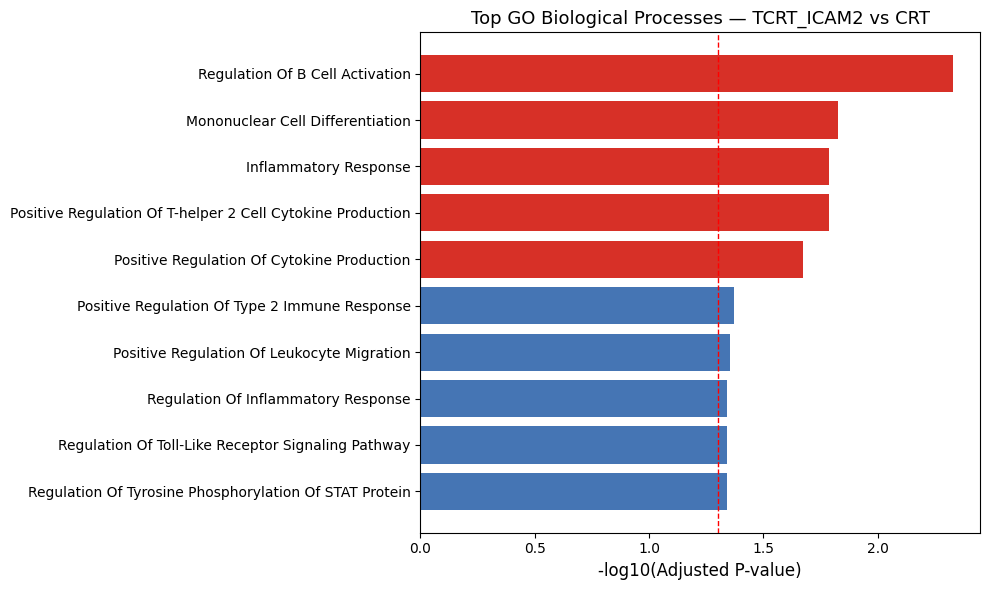

In [55]:
# Visualize top GO terms
top_go_plot = enr.results.sort_values("Adjusted P-value").head(10).copy()
top_go_plot["Term_short"] = top_go_plot["Term"].apply(
    lambda x: x.split("(GO:")[0].strip() if "(GO:" in str(x) 
    else x.split("GO:")[0].strip() if "GO:" in str(x) 
    else str(x).strip()
)
top_go_plot["-log10_adjp"] = -np.log10(top_go_plot["Adjusted P-value"])

plt.figure(figsize=(10, 6))
colors = ["#d73027" if i < 5 else "#4575b4" for i in range(len(top_go_plot))]
plt.barh(top_go_plot["Term_short"][::-1], top_go_plot["-log10_adjp"][::-1], color=colors[::-1])
plt.xlabel("-log10(Adjusted P-value)", fontsize=12)
plt.title("Top GO Biological Processes — TCRT_ICAM2 vs CRT", fontsize=13)
plt.axvline(x=-np.log10(0.05), color="red", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

Extracting the top pathway

In [56]:
# Diagnose the enrichment results
print("Shape:", enr.results.shape)
print("\nColumns:", enr.results.columns.tolist())
print("\nFirst few rows:")
print(enr.results.head())
print("\nAll unique values in Adjusted P-value column (first 5):")
print(enr.results["Adjusted P-value"].head())

Shape: (3416, 10)

Columns: ['Gene_set', 'Term', 'Overlap', 'P-value', 'Adjusted P-value', 'Old P-value', 'Old Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes']

First few rows:
                     Gene_set  \
0  GO_Biological_Process_2023   
1  GO_Biological_Process_2023   
2  GO_Biological_Process_2023   
3  GO_Biological_Process_2023   
4  GO_Biological_Process_2023   

                                                Term Overlap   P-value  \
0       Regulation Of B Cell Activation (GO:0050864)   10/25  0.000001   
1      Mononuclear Cell Differentiation (GO:1903131)    9/24  0.000009   
2                 Inflammatory Response (GO:0006954)  33/236  0.000016   
3  Positive Regulation Of T-helper 2 Cell Cytokin...     5/7  0.000019   
4  Positive Regulation Of Cytokine Production (GO...  40/320  0.000031   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.004663            0                     0    9.927340   
1          0.014957         

In [43]:
# Clean gene symbols before enrichment
import re

cleaned_genes = []
for gene in significant_genes:
    gene = str(gene).strip()           # remove whitespace
    gene = gene.split(".")[0]          # remove decimal suffixes like .1
    gene = gene.upper()                # force uppercase
    cleaned_genes.append(gene)

# Remove duplicates
cleaned_genes = list(set(cleaned_genes))
print(f"Cleaned gene list: {len(cleaned_genes)} genes")
print("Sample:", cleaned_genes[:10])

# Now run enrichr with cleaned list
enr = gp.enrichr(
    gene_list=cleaned_genes,
    gene_sets="GO_Biological_Process_2023",
    organism="hsapiens",
    outdir=None
)

print("\nResults shape:", enr.results.shape)
top_go = enr.results.sort_values("Adjusted P-value").head(15)
print(top_go[["Term", "Overlap", "P-value", "Adjusted P-value"]].to_string())

Cleaned gene list: 1267 genes
Sample: ['CDKN1B', 'PTPN3', 'LOC105371870', 'PTGIR', 'GPA33', 'FCMR', 'MAPK12', 'NFILZ', 'SPNS2', 'PLXDC1']

Results shape: (3416, 10)
                                                                       Term Overlap   P-value  Adjusted P-value
0                              Regulation Of B Cell Activation (GO:0050864)   10/25  0.000001          0.004663
1                             Mononuclear Cell Differentiation (GO:1903131)    9/24  0.000009          0.014957
2                                        Inflammatory Response (GO:0006954)  33/236  0.000016          0.016303
3   Positive Regulation Of T-helper 2 Cell Cytokine Production (GO:2000553)     5/7  0.000019          0.016303
4                   Positive Regulation Of Cytokine Production (GO:0001819)  40/320  0.000031          0.021119
5                Positive Regulation Of Type 2 Immune Response (GO:0002830)    6/13  0.000074          0.042382
6                   Positive Regulation Of Leukocyt

In [44]:
import subprocess
subprocess.run(["pip", "install", "mygene"], check=True)

CompletedProcess(args=['pip', 'install', 'mygene'], returncode=0)

In [45]:
import mygene
mg = mygene.MyGeneInfo()

# Convert your significant gene IDs to symbols
print("Converting Entrez IDs to gene symbols...")
result_conv = mg.querymany(
    cleaned_genes,
    scopes="entrezgene",
    fields="symbol",
    species="human",
    returnall=False
)

# Extract valid symbols only
symbol_list = []
for r in result_conv:
    if "symbol" in r:
        symbol_list.append(r["symbol"])

symbol_list = list(set(symbol_list))  # remove duplicates
print(f"Successfully converted: {len(symbol_list)} gene symbols")
print("Sample:", symbol_list[:10])

Converting Entrez IDs to gene symbols...


1267 input query terms found no hit:	['CDKN1B', 'PTPN3', 'LOC105371870', 'PTGIR', 'GPA33', 'FCMR', 'MAPK12', 'NFILZ', 'SPNS2', 'PLXDC1', 


Successfully converted: 0 gene symbols
Sample: []


In [47]:
top_pathways=enr.results.sort_values("Adjusted P-value").head(10)
top_pathways

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Regulation Of B Cell Activation (GO:0050864),10/25,0.000001,0.004663,0,0,9.927340,134.061177,IL10;IL4;IL4I1;IL6;THEMIS2;FCRL3;TNFSF4;SLAMF8...
1,GO_Biological_Process_2023,Mononuclear Cell Differentiation (GO:1903131),9/24,0.000009,0.014957,0,0,8.927504,103.966893,IL4;BATF3;CSF2;MT1G;LILRB1;GAS6;CLU;RELB;VEGFA
2,GO_Biological_Process_2023,Inflammatory Response (GO:0006954),33/236,0.000016,0.016303,0,0,2.441058,27.008687,CXCL9;CXCL8;C5AR2;PTGER3;ADM;GATA3;ADCY1;RELB;...
3,GO_Biological_Process_2023,Positive Regulation Of T-helper 2 Cell Cytokin...,5/7,0.000019,0.016303,0,0,37.105784,403.203092,IL4;IL6;RSAD2;NLRP3;XCL1
4,GO_Biological_Process_2023,Positive Regulation Of Cytokine Production (GO...,40/320,0.000031,0.021119,0,0,2.148446,22.310260,CSF2;AIRE;FLT4;SERPINE1;HILPDA;HTR2B;GATA3;PTG...
5,GO_Biological_Process_2023,Positive Regulation Of Type 2 Immune Response ...,6/13,0.000074,0.042382,0,0,12.728673,120.992488,IL4;IL6;RSAD2;TNFSF4;NLRP3;XCL1
6,GO_Biological_Process_2023,Positive Regulation Of Leukocyte Migration (GO...,9/31,0.000090,0.044014,0,0,6.084658,56.669898,IL4;IL6;CSF1;XCL1;ZP3;IL6R;ICAM1;JAM3;VEGFA
7,GO_Biological_Process_2023,Regulation Of Inflammatory Response (GO:0050727),31/240,0.000127,0.045457,0,0,2.222960,19.936912,SERPINE1;MGST2;GATA3;AOAH;PTGS2;METRNL;USP18;N...
8,GO_Biological_Process_2023,Regulation Of Toll-Like Receptor Signaling Pat...,7/20,0.000150,0.045457,0,0,8.000000,70.432704,GFI1;IRF1;TYRO3;SMPDL3B;TLR5;BIRC3;TLR2
9,GO_Biological_Process_2023,Regulation Of Tyrosine Phosphorylation Of STAT...,13/65,0.000186,0.045457,0,0,3.724282,31.998636,CSF2;LIF;OSM;OCRL;PARP9;VEGFA;IL4;SOCS3;IL6;SO...


Exporting Results

In [58]:
# Export full results and significant DEGs
results.to_csv("DEG_GSE330057_results_full.csv")
sig.to_csv("DEG_GSE330057_significant.csv")
enr.results.to_csv("final_results_GSE330057.csv")